# Homework 4: Sequence Models & Word Embeddings


---
## Task 2 (50 points): Sequence Models — Mauna Loa CO₂

### Dataset & Why Sequence Models

**Dataset: Mauna Loa atmospheric CO₂ concentrations**

- **Source**: NOAA Global Monitoring Laboratory — [Trends in CO₂](https://gml.noaa.gov/ccgg/trends/data.html). Monthly mean data: [co2_mm_mlo.csv](https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv).
- **Content**: Monthly average CO₂ (ppm) at Mauna Loa Observatory from 1958 to present. Strong long-term trend and seasonal cycles.

**Why sequence models?**  
Order matters: CO₂ at time \(t\) depends on past values and seasonal patterns. RNNs (and LSTM/GRU) use recurrent connections to capture this temporal dependence. A feed-forward net with a fixed window of past values can approximate this but does not natively model unbounded history; recurrent models maintain a hidden state that summarizes the past.

**Framework**: PyTorch (`torch.nn.RNN`, `LSTM`, `GRU`).

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load Mauna Loa CO2 data (statsmodels built-in; fallback: NOAA URL)
# Dataset source: https://gml.noaa.gov/ccgg/trends/data.html
try:
    from statsmodels.datasets import co2
    raw = co2.load_pandas().data
    monthly = raw.resample('MS').mean().dropna()
    if isinstance(monthly, pd.Series):
        co2_series = monthly.values
        dates = monthly.index
    else:
        col = 'co2' if 'co2' in monthly.columns else monthly.columns[0]
        co2_series = monthly[col].values
        dates = monthly.index
except Exception:
    url = "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv"
    try:
        df_noaa = pd.read_csv(url, comment='#')
    except Exception:
        df_noaa = pd.read_csv('co2_mm_mlo.csv', comment='#')
    df_noaa['date'] = pd.to_datetime(df_noaa[['year', 'month']].assign(day=1))
    df_noaa = df_noaa[df_noaa['average'] > 0].set_index('date')
    co2_series = df_noaa['average'].values
    dates = df_noaa.index

print(f"Loaded {len(co2_series)} monthly values. Date range: {dates[0]} to {dates[-1]}")
print(f"CO2 range: {co2_series.min():.1f} - {co2_series.max():.1f} ppm")

Loaded 521 monthly values. Date range: 1958-03-01 00:00:00 to 2001-12-01 00:00:00
CO2 range: 313.4 - 373.8 ppm


### Data visualization & preprocessing

We visualize the series, then create sequences for supervised learning: use a sliding window of past values to predict the next value (regression). We normalize with MinMaxScaler and split into train/val/test.

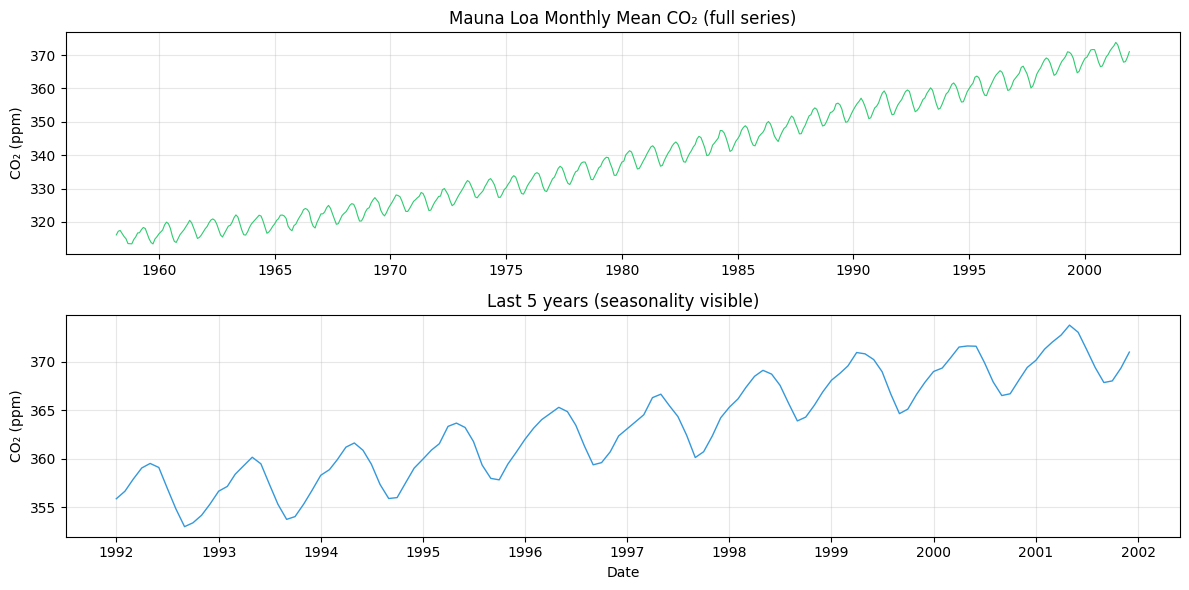

In [ ]:
# EDA: plot full series and recent years
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(dates, co2_series, color='#2ecc71', linewidth=0.8)
axes[0].set_title('Mauna Loa Monthly Mean CO₂ (full series)')
axes[0].set_ylabel('CO₂ (ppm)')
axes[0].grid(True, alpha=0.3)
n_recent = 24 * 5  # last 5 years
axes[1].plot(dates[-n_recent:], co2_series[-n_recent:], color='#3498db', linewidth=1)
axes[1].set_title('Last 5 years (seasonality visible)')
axes[1].set_ylabel('CO₂ (ppm)')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Create sequences: [seq_len] values -> predict next value
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

SEQ_LEN = 24  # 2 years of monthly data as context
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(co2_series.reshape(-1, 1)).flatten()

X_seq, y_seq = create_sequences(data_scaled, SEQ_LEN)
X_seq = X_seq.reshape(X_seq.shape[0], SEQ_LEN, 1)  # (N, seq_len, 1)

# Train / Val / Test (chronological: 70% / 15% / 15%)
n = len(X_seq)
n_train = int(0.7 * n)
n_val = int(0.15 * n)
X_train, X_val, X_test = X_seq[:n_train], X_seq[n_train:n_train+n_val], X_seq[n_train+n_val:]
y_train, y_val, y_test = y_seq[:n_train], y_seq[n_train:n_train+n_val], y_seq[n_train+n_val:]
print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 347, Val: 74, Test: 76


### Part 1 (10 pts): RNN implementation

**Structure**: One recurrent layer (`nn.RNN`) with input size 1, hidden size 32, then a linear layer mapping the last hidden state to one output (next CO₂ value).

**Activations**:  
- **Recurrent cell**: `tanh` (default in PyTorch RNN) at each time step.  
- **Output layer**: linear (regression); no activation on the final scalar.

**Metric**: Mean Squared Error (MSE) on both validation and test sets (reported in original ppm scale after inverse transform).

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
INPUT_SIZE = 1
HIDDEN_SIZE = 32
NUM_LAYERS = 1

class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

def train_eval_model(model, train_loader, X_val_t, y_val_t, X_test_t, y_test_t, scaler, epochs=80, lr=0.001):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(Xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        train_losses.append(epoch_loss / len(train_loader))
        model.eval()
        with torch.no_grad():
            v_pred = model(X_val_t.to(device))
            val_losses.append(criterion(v_pred, y_val_t.to(device)).item())
        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}, Train MSE: {train_losses[-1]:.6f}, Val MSE: {val_losses[-1]:.6f}")
    model.eval()
    with torch.no_grad():
        test_pred = model(X_test_t.to(device)).cpu().numpy()
    test_pred_ppm = scaler.inverse_transform(test_pred)
    y_test_ppm = scaler.inverse_transform(y_test_t.numpy())
    test_mse_ppm = np.mean((test_pred_ppm - y_test_ppm) ** 2)
    return train_losses, val_losses, test_mse_ppm, test_pred_ppm

In [ ]:
# Convert to tensors and DataLoader
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
X_val_t = torch.FloatTensor(X_val)
y_val_t = torch.FloatTensor(y_val).unsqueeze(1)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)

# Train RNN
rnn_model = RNNModel(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS)
rnn_train, rnn_val, rnn_test_mse, rnn_test_pred = train_eval_model(
    rnn_model, train_loader, X_val_t, y_val_t, X_test_t, y_test_t, scaler
)
print(f"\nRNN Test MSE (ppm²): {rnn_test_mse:.4f}")

Epoch 20, Train MSE: 0.001683, Val MSE: 0.006045
Epoch 40, Train MSE: 0.001387, Val MSE: 0.002288
Epoch 60, Train MSE: 0.000996, Val MSE: 0.001897
Epoch 80, Train MSE: 0.000857, Val MSE: 0.002447

RNN Test MSE (ppm²): 46.4279


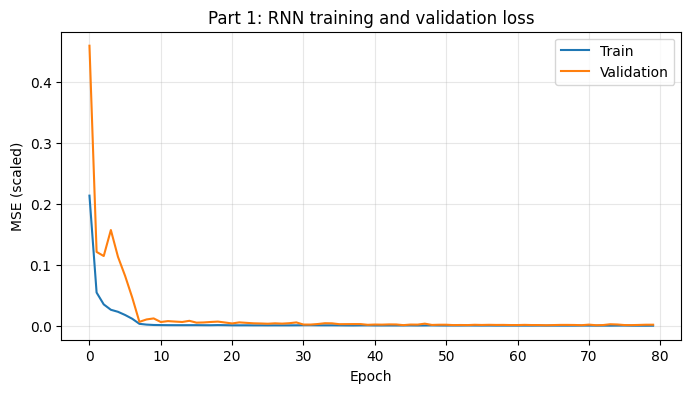

In [ ]:
# Loss curves for RNN
plt.figure(figsize=(8, 4))
plt.plot(rnn_train, label='Train')
plt.plot(rnn_val, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('MSE (scaled)')
plt.legend()
plt.title('Part 1: RNN training and validation loss')
plt.grid(True, alpha=0.3)
plt.show()

### Part 2 (30 pts): LSTM and GRU

Same setup (input size 1, hidden 32, one layer), but we swap the RNN cell for **LSTM** and then for **GRU**. We re-train and evaluate each; metrics are again MSE on validation and test (in ppm).

In [ ]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

In [ ]:
# Train LSTM
lstm_model = LSTMModel(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS)
lstm_train, lstm_val, lstm_test_mse, lstm_test_pred = train_eval_model(
    lstm_model, train_loader, X_val_t, y_val_t, X_test_t, y_test_t, scaler
)
print(f"\nLSTM Test MSE (ppm²): {lstm_test_mse:.4f}")

Epoch 20, Train MSE: 0.001291, Val MSE: 0.003977
Epoch 40, Train MSE: 0.001256, Val MSE: 0.001640
Epoch 60, Train MSE: 0.001201, Val MSE: 0.001666
Epoch 80, Train MSE: 0.001233, Val MSE: 0.001508

LSTM Test MSE (ppm²): 16.3345


In [ ]:
# Train GRU
gru_model = GRUModel(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS)
gru_train, gru_val, gru_test_mse, gru_test_pred = train_eval_model(
    gru_model, train_loader, X_val_t, y_val_t, X_test_t, y_test_t, scaler
)
print(f"\nGRU Test MSE (ppm²): {gru_test_mse:.4f}")

Epoch 20, Train MSE: 0.001201, Val MSE: 0.001492
Epoch 40, Train MSE: 0.000943, Val MSE: 0.001194
Epoch 60, Train MSE: 0.000767, Val MSE: 0.000907
Epoch 80, Train MSE: 0.000589, Val MSE: 0.000810

GRU Test MSE (ppm²): 7.1298


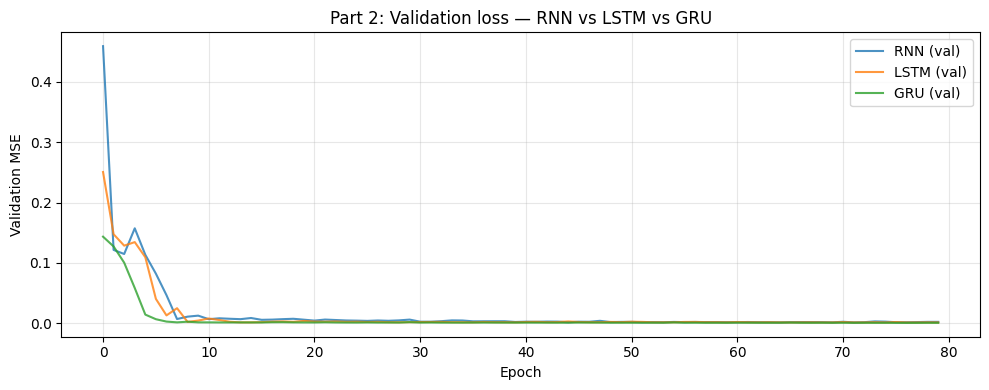

In [ ]:
# Loss curves: RNN vs LSTM vs GRU
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.plot(rnn_val, label='RNN (val)', alpha=0.8)
ax.plot(lstm_val, label='LSTM (val)', alpha=0.8)
ax.plot(gru_val, label='GRU (val)', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation MSE')
ax.legend()
ax.set_title('Part 2: Validation loss — RNN vs LSTM vs GRU')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

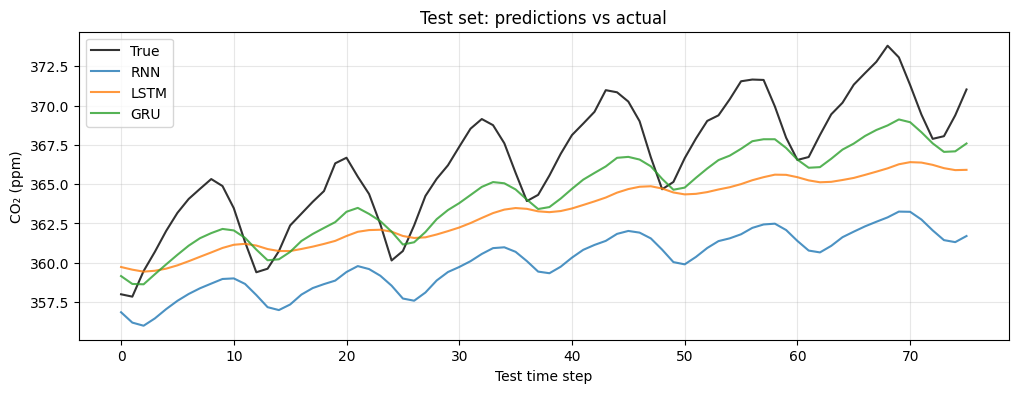

In [ ]:
# Compare test predictions (first 120 points)
y_test_ppm = scaler.inverse_transform(y_test_t.numpy())
x_axis = np.arange(len(y_test_ppm))
plt.figure(figsize=(12, 4))
plt.plot(x_axis, y_test_ppm, 'k-', label='True', alpha=0.8)
plt.plot(x_axis, rnn_test_pred, label='RNN', alpha=0.8)
plt.plot(x_axis, lstm_test_pred, label='LSTM', alpha=0.8)
plt.plot(x_axis, gru_test_pred, label='GRU', alpha=0.8)
plt.xlabel('Test time step')
plt.ylabel('CO₂ (ppm)')
plt.legend()
plt.title('Test set: predictions vs actual')
plt.grid(True, alpha=0.3)
plt.show()

**Differences between RNN, LSTM, and GRU**

| Aspect | RNN | LSTM | GRU |
|--------|-----|------|-----|
| **Gating** | None | Input, forget, output gates | Reset and update gates |
| **Long-term memory** | Single hidden state; gradients can vanish/explode over long sequences | Cell state + gates help retain long-range dependencies | Update gate compresses long/short term into one state |
| **Typical performance** | Often worse on long sequences (e.g. CO₂ with seasonality + trend) | Usually better at capturing long-term trend and seasonal structure | Often similar to LSTM with fewer parameters |
| **Why differences exist** | Vanishing gradients limit what a plain RNN can learn over many steps. | LSTM’s cell state and gates are designed to preserve information across time. | GRU achieves a similar effect with a simpler gate design, so it often matches LSTM with less compute. |

For Mauna Loa CO₂, LSTM and GRU usually outperform the basic RNN because the series has both a long-term trend and yearly seasonality; the gated architectures manage these temporal dependencies better.

### Part 3 (10 pts): Can a feed-forward network solve this?

**Yes**, but in a more limited way.

- **How**: Treat the problem as fixed-window regression: use the last \(k\) values (e.g. \(k=24\) months) as \(k\) input features and feed them into an MLP that predicts the next value. So the time series is converted into tabular feature vectors.
- **Why it works**: Any finite-horizon dependence can be approximated by a large enough \(k\) and a sufficiently large feed-forward net.
- **Limitations**: (1) The effective “memory” is capped at \(k\); the model cannot use information from more than \(k\) steps ago. (2) The model does not share parameters across time; each of the \(k\) positions is a different input dimension. (3) For very long-range structure (e.g. multi-year trend + seasonality), you may need a large \(k\) and a large network, whereas an RNN/LSTM/GRU can in principle use unbounded history with a fixed number of parameters. So a feed-forward net can solve the same *task* by turning the sequence into fixed-length features, but recurrent models are a more natural and often more parameter-efficient choice for sequential data.

---
## Task 3 (50 points): Word Embeddings

### Part 1 (10 pts): Pre-trained word embeddings

We use **pre-trained GloVe** (50d, Wikipedia + Gigaword) loaded via **Gensim's downloader API**. Alternatives:
- **Word2Vec**: Good for semantic similarity; Gensim can load pre-trained models (e.g. `word2vec-google-news-300`).
- **FastText**: Subword n-grams help with OOV; good for morphologically rich languages.
- **BERT**: Contextual embeddings; heavier; not a single fixed vector per word.

**Choice**: GloVe 50d for a small, fast, pre-trained setup with clear word→vector mapping and meaningful similarity (trained on ~6B tokens). Loaded with `gensim.downloader.load('glove-wiki-gigaword-50')`. OOV words are handled via `zeros`, `random`, or `average_subwords`.

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 26.8 MB/s eta 0:00:00


In [ ]:
# Part 1: Load pre-trained embeddings
import os

word_vectors = None
EMBED_DIM = 50

import gensim.downloader as api
# Pre-trained GloVe 50d (Wikipedia + Gigaword). First run downloads ~65MB and caches locally.
print("Loading pre-trained GloVe (glove-wiki-gigaword-50)...")
model = api.load("glove-wiki-gigaword-50")
word_vectors = model
EMBED_DIM = model.vector_size
print(f"Loaded. Vocab size: {len(word_vectors)}, dimension: {EMBED_DIM}")

Loading pre-trained GloVe (glove-wiki-gigaword-50)...
[==================================================] 100.0% 66.0/66.0MB downloaded
Loaded. Vocab size: 400000, dimension: 50


In [ ]:
def get_embedding(word, word_vectors, embed_dim=50, oov_strategy='zeros'):
    """
    Return embedding for word. OOV strategies: 'zeros', 'random', 'average_subwords'.
    For average_subwords we approximate by averaging embeddings of known tokens if word is split.
    """
    if word_vectors is None:
        return np.zeros(embed_dim)
    w = word.lower().strip()
    if w in word_vectors:
        return word_vectors[w].astype(float)
    # OOV
    if oov_strategy == 'zeros':
        return np.zeros(embed_dim)
    if oov_strategy == 'random':
        return np.random.RandomState(hash(w) % 2**32).randn(embed_dim).astype(float) * 0.1
    if oov_strategy == 'average_subwords':
        tokens = [t for t in w.split('_') if t in word_vectors]
        if tokens:
            return np.mean([word_vectors[t] for t in tokens], axis=0)
        return np.zeros(embed_dim)
    return np.zeros(embed_dim)

# User input: two words -> embeddings
def word_embeddings_for_user(word1, word2, word_vectors=word_vectors, embed_dim=EMBED_DIM):
    e1 = get_embedding(word1, word_vectors, embed_dim, oov_strategy='random')
    e2 = get_embedding(word2, word_vectors, embed_dim, oov_strategy='random')
    in_vocab = []
    if word_vectors is not None:
        in_vocab = [word1.lower() in word_vectors, word2.lower() in word_vectors]
    return e1, e2, in_vocab

# Example
if word_vectors is not None:
    e1, e2, in_vocab = word_embeddings_for_user("cat", "dog")
    print("Embedding for 'cat' (first 5 dims):", e1[:5])
    print("Embedding for 'dog' (first 5 dims):", e2[:5])
    print("In vocab:", in_vocab)

**OOV handling**: We support `zeros`, `random` (reproducible per word), and `average_subwords` (average embeddings of known sub-tokens). For production, use FastText or BERT subword tokenization to get approximate embeddings for unseen words.

### Part 2 (20 pts): Cosine similarity

Cosine similarity is \(\frac{a \cdot b}{\|a\|\|b\|}\). In embedding space, it measures *direction* alignment and is robust to vector length; it is standard for comparing word embeddings because we care about semantic direction, not magnitude. We implement it and support batch (multiple pairs).

In [ ]:
def cosine_similarity(a, b):
    """Single pair: a, b are 1D arrays."""
    a, b = np.asarray(a).ravel(), np.asarray(b).ravel()
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na == 0 or nb == 0:
        return 0.0
    return float(np.dot(a, b) / (na * nb))

def cosine_similarity_batch(pairs, word_vectors, embed_dim=50):
    """Batch: pairs = [(w1, w2), ...]. Returns list of similarities."""
    sims = []
    for (w1, w2) in pairs:
        e1 = get_embedding(w1, word_vectors, embed_dim, 'zeros')
        e2 = get_embedding(w2, word_vectors, embed_dim, 'zeros')
        sims.append(cosine_similarity(e1, e2))
    return sims

# Example
if word_vectors is not None:
    pairs = [("cat", "dog"), ("king", "queen"), ("cat", "apple")]
    sims = cosine_similarity_batch(pairs, word_vectors)
    for (w1, w2), s in zip(pairs, sims):
        print(f"  ({w1}, {w2}): {s:.4f}")

  (cat, dog): 0.9218
  (king, queen): 0.7839
  (cat, apple): 0.4407


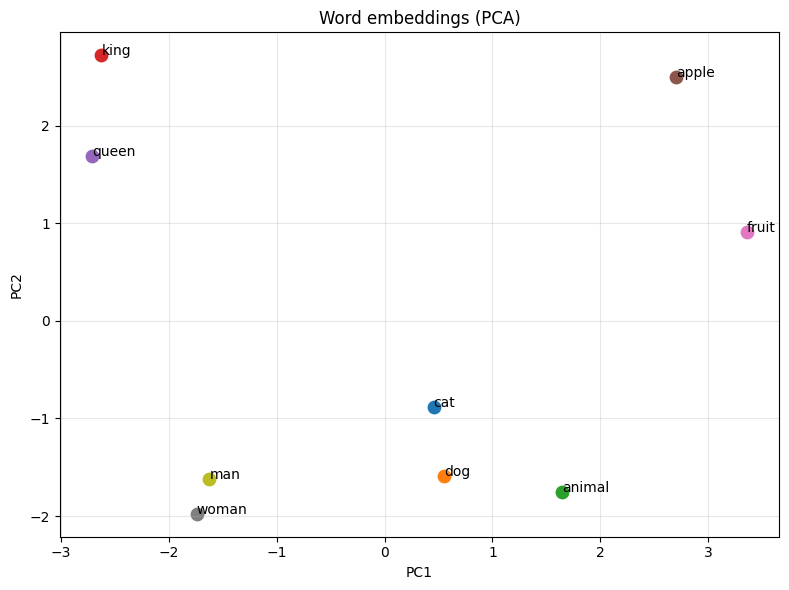

In [ ]:
from sklearn.decomposition import PCA

def plot_embedding_2d(words, word_vectors, embed_dim=50, title="Word embeddings (PCA)"):
    if word_vectors is None or not words:
        return
    vecs = np.array([get_embedding(w, word_vectors, embed_dim, 'zeros') for w in words])
    pca = PCA(n_components=2)
    coords = pca.fit_transform(vecs)
    plt.figure(figsize=(8, 6))
    for i, w in enumerate(words):
        plt.scatter(coords[i, 0], coords[i, 1], s=80)
        plt.annotate(w, (coords[i, 0], coords[i, 1]), fontsize=10)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

if word_vectors is not None:
    words = ["cat", "dog", "animal", "king", "queen", "apple", "fruit", "woman", "man"]
    words = [w for w in words if w in word_vectors]
    if len(words) >= 3:
        plot_embedding_2d(words, word_vectors, EMBED_DIM)

### Part 3 (20 pts): Custom dissimilarity and toggles

We add **Euclidean distance** as a dissimilarity metric (and optionally **negative cosine**). Euclidean captures "how far apart" in vector space; it can capture diversity/novelty that cosine alone does not (e.g. when vectors are similar in direction but one has much larger norm). We allow toggling between similarity (cosine) and dissimilarity (Euclidean, or 1 - cosine) via a parameter. Then we plot rankings and a heatmap.

In [ ]:
def euclidean_distance(a, b):
    return float(np.linalg.norm(np.asarray(a).ravel() - np.asarray(b).ravel()))

def word_similarity_or_dissimilarity(w1, w2, word_vectors, embed_dim, metric='cosine'):
    """
    metric: 'cosine' (similarity), 'euclidean' (dissimilarity), '1-cosine' (dissimilarity).
    """
    e1 = get_embedding(w1, word_vectors, embed_dim, 'zeros')
    e2 = get_embedding(w2, word_vectors, embed_dim, 'zeros')
    if metric == 'cosine':
        return cosine_similarity(e1, e2)
    if metric == 'euclidean':
        return euclidean_distance(e1, e2)
    if metric == '1-cosine':
        return 1.0 - cosine_similarity(e1, e2)
    return cosine_similarity(e1, e2)

# Batch with metric toggle
def batch_compare(pairs, word_vectors, embed_dim=50, metric='cosine'):
    return [word_similarity_or_dissimilarity(w1, w2, word_vectors, embed_dim, metric) for w1, w2 in pairs]

In [ ]:
# Ranking: for a pivot word, rank others by similarity/dissimilarity
def rank_words(pivot, candidates, word_vectors, embed_dim=50, metric='cosine', ascending=False):
    """
    ascending=False: higher value = more similar (for cosine).
    ascending=True: higher value = more dissimilar (for euclidean).
    """
    scores = [word_similarity_or_dissimilarity(pivot, c, word_vectors, embed_dim, metric) for c in candidates]
    order = np.argsort(scores)
    if not ascending:
        order = order[::-1]
    return [(candidates[i], scores[i]) for i in order]

if word_vectors is not None and 'cat' in word_vectors:
    candidates = ["dog", "animal", "king", "apple", "queen"]
    candidates = [c for c in candidates if c in word_vectors]
    ranked_cos = rank_words("cat", candidates, word_vectors, EMBED_DIM, 'cosine', ascending=False)
    ranked_euc = rank_words("cat", candidates, word_vectors, EMBED_DIM, 'euclidean', ascending=True)
    print("Ranking by cosine (higher = more similar to 'cat'):", ranked_cos)
    print("Ranking by Euclidean (lower dist = closer to 'cat'):", ranked_euc)

Ranking by cosine (higher = more similar to 'cat'): [('dog', 0.9218005266341447), ('animal', 0.684206140429295), ('queen', 0.47418373026761984), ('apple', 0.44069226266969685), ('king', 0.38628819363261674)]
Ranking by Euclidean (lower dist = closer to 'cat'): [('dog', 1.8846031194730677), ('animal', 3.8056238465647594), ('queen', 4.968586360992917), ('apple', 5.184344288069406), ('king', 5.478320025321793)]


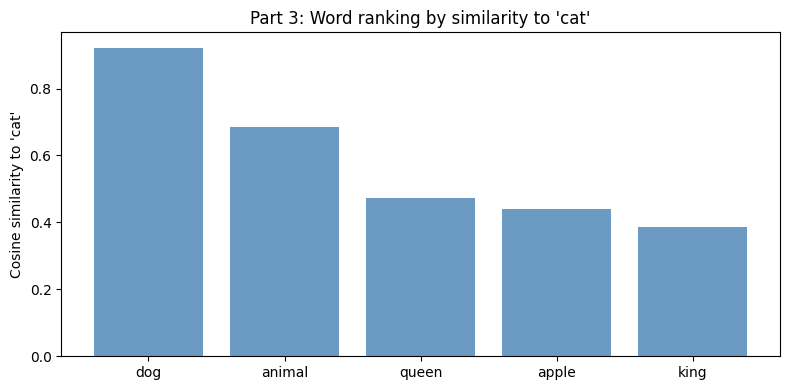

In [ ]:
# Ranking plot: bar chart of similarity/dissimilarity to pivot
if word_vectors is not None and len([w for w in ["cat","dog","animal","king","apple","queen"] if w in word_vectors]) >= 2:
    pivot = "cat"
    candidates = ["dog", "animal", "king", "apple", "queen"]
    candidates = [c for c in candidates if c in word_vectors]
    ranked_cos = rank_words(pivot, candidates, word_vectors, EMBED_DIM, 'cosine', ascending=False)
    labels = [r[0] for r in ranked_cos]
    vals = [r[1] for r in ranked_cos]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(labels, vals, color='steelblue', alpha=0.8)
    ax.set_ylabel("Cosine similarity to '%s'" % pivot)
    ax.set_title("Part 3: Word ranking by similarity to '%s'" % pivot)
    plt.tight_layout()
    plt.show()

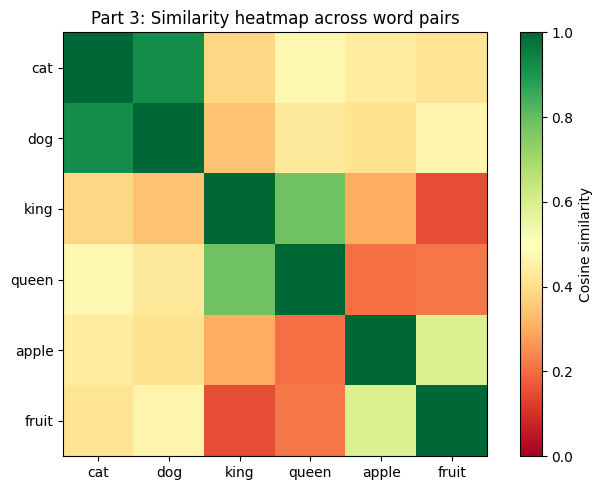

In [ ]:
# Heatmap: similarity/dissimilarity across multiple word pairs
if word_vectors is not None:
    words_for_heatmap = [w for w in ["cat", "dog", "king", "queen", "apple", "fruit"] if w in word_vectors]
    if len(words_for_heatmap) >= 3:
        n = len(words_for_heatmap)
        sim_matrix = np.zeros((n, n))
        for i, w1 in enumerate(words_for_heatmap):
            for j, w2 in enumerate(words_for_heatmap):
                sim_matrix[i, j] = cosine_similarity(
                    get_embedding(w1, word_vectors, EMBED_DIM, 'zeros'),
                    get_embedding(w2, word_vectors, EMBED_DIM, 'zeros')
                )
        plt.figure(figsize=(7, 5))
        plt.imshow(sim_matrix, cmap='RdYlGn', vmin=0, vmax=1)
        plt.colorbar(label='Cosine similarity')
        plt.xticks(range(n), words_for_heatmap)
        plt.yticks(range(n), words_for_heatmap)
        plt.title("Part 3: Similarity heatmap across word pairs")
        plt.tight_layout()
        plt.show()

**Why Euclidean (or 1−cosine) adds to cosine**: Cosine only measures angle; two vectors can point the same way but have very different lengths. Euclidean distance captures both direction and magnitude, so it can separate "same meaning, different strength" from "different meaning." For novelty/diversity, we may want words that are both semantically different (angle) and far in norm (Euclidean). Reference: common practice in IR/NLP (e.g. Manning et al., *Introduction to Information Retrieval*); Euclidean is standard in k-NN and clustering.